In [ ]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install lightgbm
!pip install seaborn

# Loading the data

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('Data2026/measures.csv', sep=";", decimal=",")
df_subject = df["subject"]
df_y = df["activity"]
df = df.drop("subject", axis=1).drop("activity", axis=1)

df_to_predict = pd.read_csv('Data2026/to_predict.csv', sep=";", decimal=",")
df_to_predict_subject = df_to_predict["subject"]
df_to_predict = df_to_predict.drop("subject", axis=1)


In [26]:
df

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.070157,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,0.165259,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.195034,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,0.013865,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339


In [27]:
df_to_predict

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.295787,-0.001185,-0.086497,-0.984676,-0.952503,-0.970502,-0.987196,-0.954779,-0.971006,-0.917885,...,0.054684,0.228329,-0.062695,0.021257,0.105143,0.197985,0.785929,-0.547155,0.410914,0.020175
1,0.270150,-0.031853,-0.136383,-0.994822,-0.985789,-0.980709,-0.995307,-0.985891,-0.984729,-0.939793,...,0.452095,-0.432503,-0.724345,-0.023479,-0.155946,-0.111944,0.114424,-0.825642,0.187788,0.101844
2,0.290129,-0.008107,-0.123638,-0.965673,-0.942580,-0.925038,-0.967477,-0.938631,-0.922535,-0.909106,...,0.248597,-0.645135,-0.892432,0.130222,0.284798,0.347464,-0.058713,0.327736,-0.242665,-0.718599
3,0.302384,0.028733,-0.017861,-0.408229,-0.255241,-0.181043,-0.441548,-0.279299,-0.182820,-0.332327,...,0.349363,-0.504416,-0.802370,0.234279,-0.735805,0.902250,-0.298074,-0.507293,0.311143,0.285388
4,0.273060,-0.039085,-0.132481,-0.897547,-0.682705,-0.766239,-0.937664,-0.682806,-0.750974,-0.757252,...,-0.155270,-0.190167,-0.564601,0.011825,-0.057818,0.235715,0.520903,-0.856632,0.182028,-0.037386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.361668,-0.019977,-0.073653,-0.114561,-0.248300,-0.119782,-0.156643,-0.307619,-0.157419,0.332351,...,0.081996,0.178064,-0.175709,-0.524856,-0.846850,-0.975037,0.678709,-0.824198,0.146268,0.134895
2943,0.270503,-0.016425,-0.113275,-0.994760,-0.996642,-0.993621,-0.995434,-0.996543,-0.993672,-0.938375,...,0.361594,-0.401433,-0.748557,-0.005122,0.108525,0.725009,-0.586381,0.620117,-0.846696,-0.145531
2944,0.309384,-0.029392,-0.097839,-0.358954,-0.318693,-0.225000,-0.391279,-0.320523,-0.229465,-0.133035,...,0.070237,-0.463365,-0.805025,-0.258501,0.872098,0.926234,-0.805330,-0.571828,0.024299,0.316851
2945,0.220367,-0.031853,-0.125031,-0.197673,-0.147148,-0.433963,-0.266427,-0.183870,-0.459502,-0.027610,...,-0.132443,0.031240,-0.252663,0.634928,-0.718829,0.445230,-0.059298,-0.914612,0.046713,-0.019016


# Are there any duplicate columns or missing values in the data?

In [29]:
print(f"Total null-values in training data: {df.isnull().sum().sum()}")
print(f"Total null-values in to-predict data: {df_to_predict.isnull().sum().sum()}")

Total null-values in training data: 0
Total null-values in to-predict data: 0


In [30]:
print(f"Are there duplicated columns in training data? {df.columns.duplicated().any()}")
print(f"Are there duplicated columns in to-predict data? {df_to_predict.columns.duplicated().any()}")

Are there duplicated columns in training data? False
Are there duplicated columns in to-predict data? False


In [31]:
print(f"Are there duplicated rows in training data? {df.duplicated().any()}")
print(f"Are there duplicated rows in to-predict data? {df_to_predict.duplicated().any()}")

Are there duplicated rows in training data? False
Are there duplicated rows in to-predict data? False


# Does the data lie between -1 and 1 or should it be transformed?

In [85]:
print(f"Any values less than -1 in the training data? {(df < -1).any().any()}")
print(f"Any values greater than +1 in the training data? {(df > 1).any().any()}")

print(f"Any values less than -1 in the to-predict data? {(df_to_predict < -1).any().any()}")
print(f"Any values greater than +1 in the to-predict data? {(df_to_predict > 1).any().any()}")

Any values less than -1 in the training data? False
Any values greater than +1 in the training data? False
Any values less than -1 in the to-predict data? False
Any values greater than +1 in the to-predict data? False


In [7]:
ranges = df.max() - df.min()
sorted_ranges = ranges.sort_values(ascending=True)
print(sorted_ranges)
#print(df["tGravityAcc-max()-Y"].max())
#print(df["tGravityAcc-max()-Y"].min())

tGravityAcc-max()-Y          1.462182
fBodyGyro-min()-X            1.465197
angle(Y,gravityMean)         1.478157
tGravityAcc-mean()-Y         1.535222
tGravityAcc-arCoeff()-Z,4    1.554000
                               ...   
tBodyAcc-iqr()-Y             2.000000
tBodyAcc-iqr()-X             2.000000
tBodyAcc-energy()-Z          2.000000
tBodyAcc-energy()-X          2.000000
tBodyAcc-mean()-X            2.000000
Length: 561, dtype: float64


In [86]:
devFactor = 0.05
cols = df.columns[(df.max() - df.min()) < (2-devFactor*2)].tolist()
print(f"The following {len(cols)} columns don't span the entire -1 to 1 range: They span ranges that deviate at least by {devFactor*100}% from the whole range")
for col in cols:
    print(col)
    print(f"Min: {df[col].min()}; Max: {df[col].max()}")

The following 61 columns don't span the entire -1 to 1 range: They span ranges that deviate at least by 5.0% from the whole range
tBodyAcc-arCoeff()-X,4
Min: -0.82205333; Max: 1.0
tBodyAcc-arCoeff()-Z,1
Min: -1.0; Max: 0.81462304
tBodyAcc-arCoeff()-Z,2
Min: -0.75375375; Max: 1.0
tGravityAcc-mean()-Y
Min: -0.53522237; Max: 1.0
tGravityAcc-max()-Y
Min: -0.49387412; Max: 0.96830748
tGravityAcc-min()-Y
Min: -0.56815651; Max: 1.0
tGravityAcc-arCoeff()-Y,1
Min: -1.0; Max: 0.81316975
tGravityAcc-arCoeff()-Z,1
Min: -1.0; Max: 0.64877436
tGravityAcc-arCoeff()-Z,2
Min: -0.61763642; Max: 1.0
tGravityAcc-arCoeff()-Z,3
Min: -1.0; Max: 0.58576939
tGravityAcc-arCoeff()-Z,4
Min: -0.55400018; Max: 1.0
tBodyAccJerk-std()-Y
Min: -1.0; Max: 0.80707793
tBodyAccJerk-max()-Y
Min: -1.0; Max: 0.62437285
tBodyAccJerk-min()-Y
Min: -0.74690717; Max: 1.0
tBodyAccJerk-energy()-Y
Min: -1.0; Max: 0.63441522
tBodyAccJerk-arCoeff()-Z,2
Min: -0.79906863; Max: 1.0
tBodyGyro-mean()-X
Min: -0.91404957; Max: 0.73895313
tBod

# Are there any anomalies in the data?

In [95]:
# Check for abnormally rare classes
df_y.value_counts(normalize=True)

activity
LAYING                0.191376
STANDING              0.186888
SITTING               0.174918
WALKING               0.166757
WALKING_UPSTAIRS      0.145947
WALKING_DOWNSTAIRS    0.134113
Name: proportion, dtype: float64

In [96]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tBodyAcc-mean()-X,7352.0,0.274488,0.070261,-1.000000,0.262975,0.277193,0.288461,1.000000
tBodyAcc-mean()-Y,7352.0,-0.017695,0.040811,-1.000000,-0.024863,-0.017219,-0.010783,1.000000
tBodyAcc-mean()-Z,7352.0,-0.109141,0.056635,-1.000000,-0.120993,-0.108676,-0.097794,1.000000
tBodyAcc-std()-X,7352.0,-0.605438,0.448734,-1.000000,-0.992754,-0.946196,-0.242813,1.000000
tBodyAcc-std()-Y,7352.0,-0.510938,0.502645,-0.999873,-0.978129,-0.851897,-0.034231,0.916238
...,...,...,...,...,...,...,...,...
"angle(tBodyGyroMean,gravityMean)",7352.0,0.008726,0.608303,-1.000000,-0.482273,0.008735,0.506187,0.998702
"angle(tBodyGyroJerkMean,gravityMean)",7352.0,-0.005981,0.477975,-1.000000,-0.376341,-0.000368,0.359368,0.996078
"angle(X,gravityMean)",7352.0,-0.489547,0.511807,-1.000000,-0.812065,-0.709417,-0.509079,1.000000
"angle(Y,gravityMean)",7352.0,0.058593,0.297480,-1.000000,-0.017885,0.182071,0.248353,0.478157


In [97]:
# Z-score anomalies?
z_scores = np.abs((df - df.mean()) / df.std())
outliers = (z_scores > 6).any(axis=1)
# No, otherwise there would be too many "anomalies". That would be like 30% of the data set.
df[outliers]

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
25,0.278993,-0.014531,-0.106596,-0.998060,-0.986070,-0.993424,-0.998059,-0.985192,-0.995018,-0.942559,...,0.677073,-0.715462,-0.937483,0.025652,0.066503,-0.226316,-0.225358,-0.762197,0.262090,0.029404
27,0.144504,0.189263,0.062769,-0.904300,-0.181937,-0.443151,-0.901100,-0.110813,-0.400599,-0.931896,...,-0.257607,0.156185,-0.241781,0.013526,0.043354,0.021485,0.046689,-0.667085,0.054216,-0.218875
46,0.278538,-0.016173,-0.109707,-0.996646,-0.982975,-0.994798,-0.996950,-0.981852,-0.993458,-0.943243,...,0.334327,-0.659341,-0.915199,-0.108092,0.371172,-0.500428,0.454992,-0.646254,-0.016451,-0.207666
60,0.276729,-0.017210,-0.105638,-0.994788,-0.991031,-0.993187,-0.995890,-0.990625,-0.992795,-0.933459,...,0.918576,-0.860312,-0.979142,-0.328275,0.447151,0.079284,-0.108642,0.397134,-0.544680,-0.432871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7264,0.314157,-0.030976,-0.075438,-0.264854,-0.097578,-0.097462,-0.346561,-0.123201,-0.091154,0.133080,...,0.271736,-0.170156,-0.492774,-0.379983,0.890300,-0.217293,-0.200366,-0.863739,0.192230,0.012228
7288,0.344431,-0.017930,-0.167810,-0.262309,-0.144215,-0.072121,-0.318303,-0.146054,-0.084965,-0.017236,...,0.214276,-0.428344,-0.761927,-0.367798,-0.275429,0.197873,0.275814,-0.900862,0.164168,-0.001780
7290,0.283921,-0.026589,-0.119525,-0.275639,-0.082424,-0.067783,-0.319503,-0.073029,-0.072464,0.021704,...,-0.013559,-0.338436,-0.608658,-0.172714,0.598862,0.391946,0.118377,-0.896800,0.168436,0.004581
7321,0.324216,-0.044241,-0.184564,0.129899,0.299774,-0.143976,0.080456,0.103530,-0.148787,0.588099,...,-0.114324,-0.209017,-0.632705,-0.155177,-0.563769,-0.944006,-0.701732,-0.893186,0.124049,-0.055416


In [98]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.01, random_state=42)
pred = iso.fit_predict(df)
scores = iso.decision_function(df)

In [99]:
df['anomaly'] = (pred == -1)
df[df['anomaly']]

/tmp/ipykernel_6170/3496822150.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['anomaly'] = (pred == -1)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",anomaly
487,0.277054,-0.025719,-0.238818,0.389135,0.459064,-0.165867,0.257325,0.451692,-0.188610,0.680338,...,-0.718762,-0.934517,-0.083317,-0.044290,0.923993,0.941121,-0.722247,0.271045,0.103025,True
1266,0.251768,-0.039279,-0.145241,0.502547,0.335070,-0.090495,0.390726,0.256725,-0.052314,0.645620,...,-0.231694,-0.639939,0.137165,-0.808041,0.942684,-0.817923,-0.824367,0.217908,-0.002882,True
1267,0.433014,-0.026704,-0.097401,0.537056,0.323446,-0.298923,0.465817,0.175617,-0.276886,0.645620,...,-0.041455,-0.444029,-0.937468,-0.517382,0.948838,0.289140,-0.821163,0.221396,0.007828,True
1268,0.298099,-0.047729,-0.085959,0.311091,0.550953,-0.069220,0.249055,0.374530,-0.136046,0.592611,...,-0.310820,-0.716874,-0.253756,0.768559,0.921452,-0.327927,-0.821594,0.220333,0.000465,True
1269,0.141431,-0.027866,-0.148075,0.298526,0.440422,-0.000691,0.231787,0.339881,-0.071751,0.561661,...,-0.197165,-0.554614,0.666256,-0.012437,0.887252,-0.497485,-0.804302,0.230476,-0.011154,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5016,0.261825,-0.014344,-0.157813,0.247483,0.190260,0.666909,0.112239,0.242686,0.457588,0.550072,...,-0.191510,-0.561370,0.049536,-0.811153,0.884812,-0.757064,-0.844791,0.150938,0.115870,True
5022,0.498049,-0.033902,-0.108278,0.317016,0.221836,0.292343,0.203234,0.169955,0.267100,0.667429,...,-0.628947,-0.886811,-0.879104,0.472002,0.824867,-0.793957,-0.813839,0.159490,0.136233,True
5029,0.319424,-0.057070,-0.034659,0.228304,0.248931,0.410613,0.134494,0.271334,0.312025,0.742717,...,-0.476175,-0.804275,-0.119609,-0.482176,-0.883638,-0.163836,-0.809924,0.162908,0.137412,True
5030,0.418690,-0.016094,-0.143600,0.124667,0.235236,0.620054,0.010596,0.219037,0.501622,0.742717,...,-0.168815,-0.567528,-0.831126,0.549477,-0.634552,0.730198,-0.825332,0.166843,0.121705,True


In [101]:
df["score"] = scores
df_sorted = df.sort_values("score")
df_sorted.head(20)

/tmp/ipykernel_6170/567068732.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["score"] = scores


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",anomaly,score
3935,0.418868,-0.000011,-0.103503,0.876942,0.729609,0.551648,0.852822,0.644811,0.542567,0.907994,...,-0.334419,-0.638834,-0.558603,0.965174,0.056948,-0.708794,0.239055,0.165807,True,-0.125256
3934,0.028502,-0.012144,-0.097018,0.793422,0.916238,0.730133,0.761451,0.865956,0.681404,0.683437,...,-0.626200,0.893470,0.536252,0.812812,0.067803,-0.723711,0.228629,0.161748,True,-0.114710
3930,0.309998,0.041904,-0.105954,0.657785,0.562952,0.398943,0.634664,0.464848,0.261347,0.646970,...,-0.802885,-0.002583,-0.861994,0.908530,-0.629753,-0.710140,0.228412,0.174910,True,-0.113400
3936,0.617597,-0.008101,-0.065791,0.786675,0.419288,0.388652,0.780326,0.377150,0.368848,0.907994,...,-0.517201,-0.700399,-0.516792,0.939166,-0.241794,-0.726711,0.226650,0.160792,True,-0.111631
3937,0.250363,-0.025679,-0.208575,0.659100,0.546987,0.336739,0.639968,0.490424,0.268665,0.701397,...,-0.670121,-0.017371,-0.820398,0.672281,-0.248111,-0.756564,0.207740,0.150232,True,-0.107123
3939,0.114180,-0.042243,-0.118167,1.000000,0.753928,0.217305,1.000000,0.722617,0.179957,1.000000,...,-0.509677,0.586616,0.818511,-0.863211,-0.255721,-0.668652,0.228409,0.212093,True,-0.101497
3955,0.334074,-0.013999,-0.075121,0.647372,0.533448,0.485609,0.655247,0.525020,0.401803,0.582409,...,-0.901834,-0.276216,-0.935125,0.954753,-0.734789,-0.605327,0.234972,0.260662,True,-0.098537
3954,0.433434,-0.020786,-0.230272,0.638776,0.633313,0.470354,0.640560,0.674962,0.291976,0.757892,...,-0.589773,-0.614617,0.654223,0.931024,0.378686,-0.624776,0.239592,0.241346,True,-0.093860
3938,-0.161088,-0.028160,-0.209931,0.817104,0.873037,0.127390,0.734566,0.845695,0.111837,0.803192,...,-0.864934,0.621322,-0.820087,0.351063,0.193917,-0.729349,0.208647,0.174249,True,-0.091147
3932,0.294228,-0.043342,-0.075600,0.617049,0.478013,0.299535,0.604150,0.433964,0.180043,0.568323,...,-0.550280,-0.124996,0.558157,-0.197023,-0.505054,-0.777296,0.200526,0.137249,True,-0.088931


In [102]:
df["activity"] = df_y
df.groupby("activity")["score"].mean().sort_values()

/tmp/ipykernel_6170/1163593733.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["activity"] = df_y


activity
WALKING_DOWNSTAIRS    0.100044
WALKING_UPSTAIRS      0.135409
WALKING               0.136217
LAYING                0.187235
SITTING               0.202197
STANDING              0.203781
Name: score, dtype: float64

In [11]:
closest_row = df.loc[df.abs().sum(axis=1).idxmin()]
farthest_row = df.loc[df.abs().sum(axis=1).idxmax()]
print(closest_row)
print(farthest_row)

tBodyAcc-mean()-X                       0.210137
tBodyAcc-mean()-Y                      -0.031197
tBodyAcc-mean()-Z                      -0.058839
tBodyAcc-std()-X                       -0.019117
tBodyAcc-std()-Y                        0.222696
                                          ...   
angle(tBodyGyroMean,gravityMean)        0.589432
angle(tBodyGyroJerkMean,gravityMean)   -0.894693
angle(X,gravityMean)                   -0.763172
angle(Y,gravityMean)                    0.220375
angle(Z,gravityMean)                    0.130488
Name: 3926, Length: 561, dtype: float64
tBodyAcc-mean()-X                       0.280362
tBodyAcc-mean()-Y                      -0.017077
tBodyAcc-mean()-Z                      -0.107638
tBodyAcc-std()-X                       -0.998526
tBodyAcc-std()-Y                       -0.996814
                                          ...   
angle(tBodyGyroMean,gravityMean)        0.680198
angle(tBodyGyroJerkMean,gravityMean)   -0.392106
angle(X,gravityMean)         

# Which features correlate strongly with the class?

In [12]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_y = le.fit_transform(df_y)
mi = mutual_info_classif(df, df_y, random_state=42)
scores = pd.Series(mi, index=df.columns)

with pd.option_context('display.max_rows', 10, 'display.max_columns', None):  # more options can be specified also
    print(scores.sort_values(ascending=False).head(10))

tBodyAcc-max()-X               1.006893
tGravityAcc-min()-Y            0.944219
tBodyAccJerk-max()-X           0.937857
tGravityAcc-max()-Y            0.928346
tBodyAccMag-max()              0.904677
tGravityAccMag-max()           0.904643
tBodyAccJerk-max()-Y           0.892837
fBodyAcc-std()-X               0.890931
fBodyAcc-bandsEnergy()-1,16    0.890793
fBodyAcc-bandsEnergy()-1,8     0.887700
dtype: float64


# Boxplot of important characteristics above the class

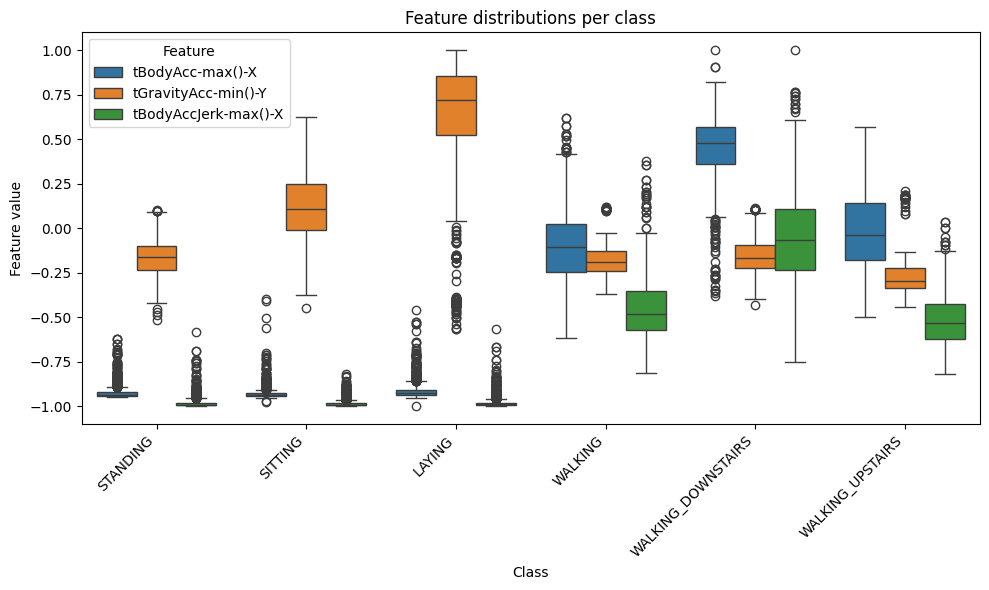

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

top_3 = scores.sort_values(ascending=False).head(3)
top_3 = list(dict(top_3).keys())

newdf = df[top_3].copy()
newdf['class'] = df_y

# 3. Melt into long format
df_melted = newdf.melt(
    id_vars='class',
    value_vars=top_3,
    var_name='feature',
    value_name='value'
)

# 4. Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_melted,
    x='class',
    y='value',
    hue='feature'
)

plt.title("Feature distributions per class")
plt.xlabel("Class")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Feature value")
plt.legend(title="Feature")
plt.tight_layout()
plt.show()

# Correlation matrix of features

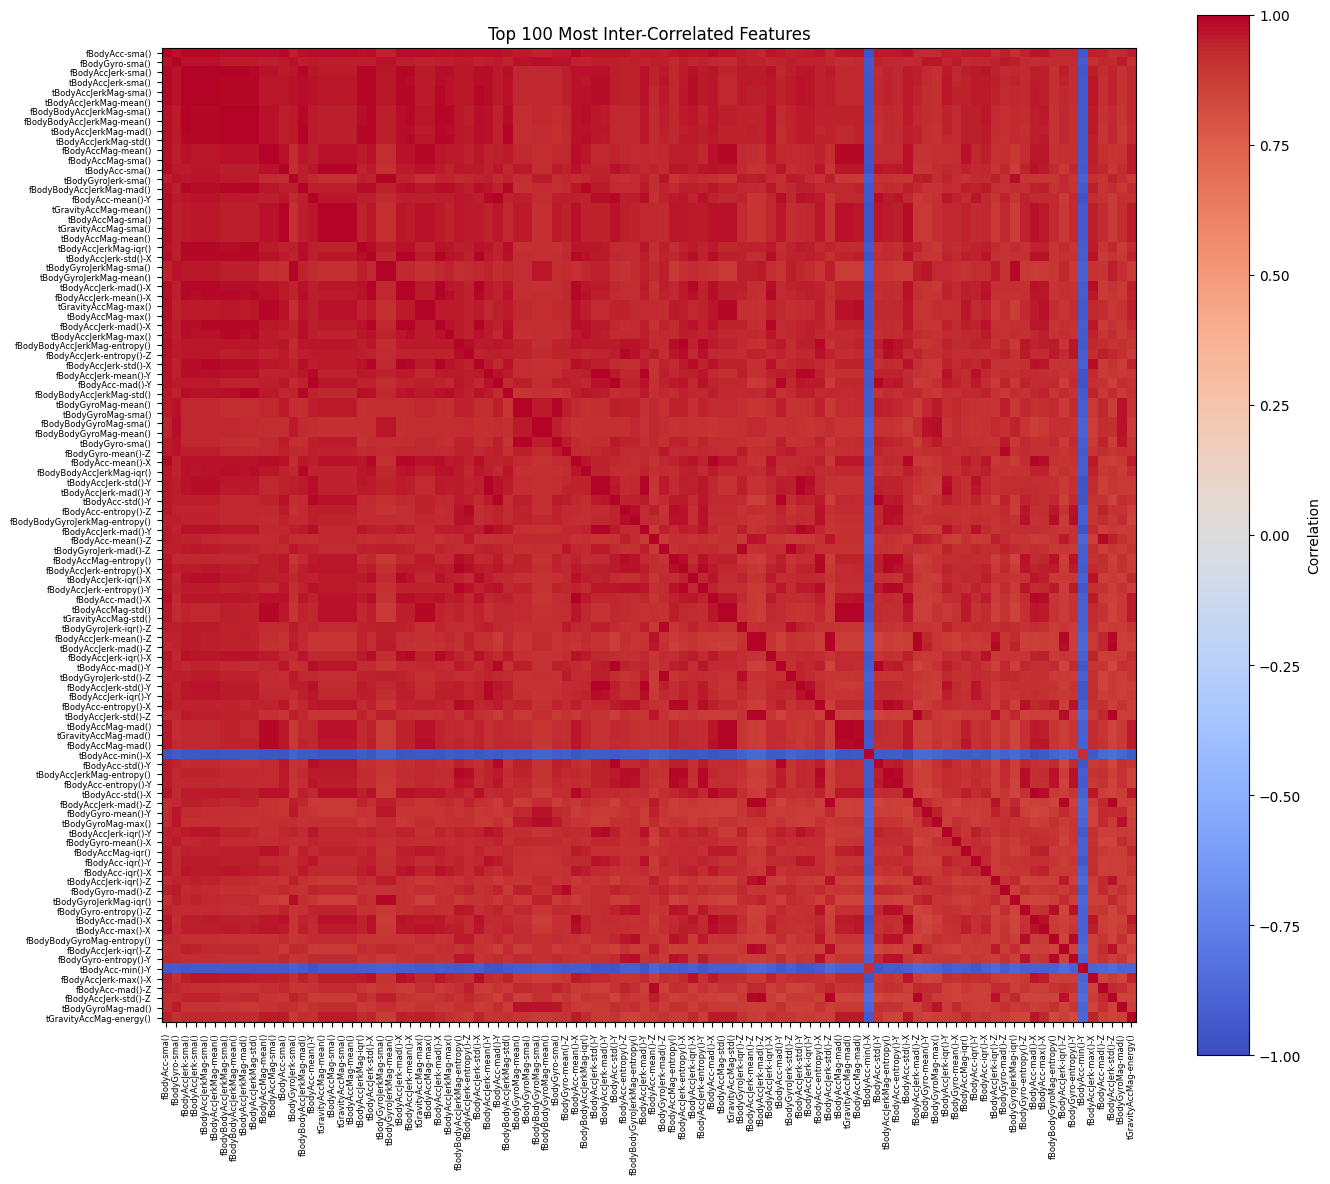

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

# 2. Score each feature by overall correlation strength
# (mean absolute correlation with all other features)
corr_strength = corr.abs().mean().sort_values(ascending=False)

# 3. Take top 100 features
top_features = corr_strength.head(100).index

# 4. Subset correlation matrix
top_corr = corr.loc[top_features, top_features]

# 5. Plot heatmap
plt.figure(figsize=(14, 12))
plt.imshow(top_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')

plt.xticks(range(len(top_features)), top_features, rotation=90, fontsize=6)
plt.yticks(range(len(top_features)), top_features, fontsize=6)

plt.title("Top 100 Most Inter-Correlated Features")
plt.tight_layout()
plt.show()


# Strongest correlations, scatterplot of the most strongly correlated features

In [73]:
def top_correlated_pairs(df, n=5, method="pearson"):
    # compute correlation matrix
    corr = df.corr(method=method)

    # take absolute value
    abs_corr = corr.abs()

    # mask upper triangle + diagonal to avoid duplicates
    mask = np.triu(np.ones_like(abs_corr, dtype=bool))
    abs_corr = abs_corr.mask(mask)

    # stack into long format
    corr_pairs = (
        abs_corr.stack()
        .reset_index()
    )

    corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

    # sort by strongest correlation
    top_pairs = corr_pairs.sort_values("correlation", ascending=False).head(n)

    return top_pairs


top5 = top_correlated_pairs(df, n=9)
top5

,feature_1,feature_2,correlation
292235,fBodyBodyAccJerkMag-sma(),fBodyBodyAccJerkMag-mean(),1.0
284929,fBodyAccMag-sma(),fBodyAccMag-mean(),1.0
306847,fBodyBodyGyroJerkMag-sma(),fBodyBodyGyroJerkMag-mean(),1.0
299541,fBodyBodyGyroMag-sma(),fBodyBodyGyroMag-mean(),1.0
115205,tBodyAccMag-sma(),tBodyAccMag-mean(),1.0
126437,tGravityAccMag-arCoeff()4,tBodyAccMag-arCoeff()4,1.0
124751,tGravityAccMag-arCoeff()1,tBodyAccMag-arCoeff()1,1.0
124189,tGravityAccMag-entropy(),tBodyAccMag-entropy(),1.0
123627,tGravityAccMag-iqr(),tBodyAccMag-iqr(),1.0


In [80]:
def plot_feature_pairs_scatter(df, feature_pairs, alpha=0.5, s=15, figsize=(4, 4)):
    """
    Create scatter plots for given feature pairs.

    Parameters:
    - df: pandas DataFrame
    - feature_pairs: list of tuples [(f1, f2), ...]
    - alpha: transparency of points
    - s: marker size
    - figsize: size of each plot
    """

    n = len(feature_pairs)
    cols = 3
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0]*cols, figsize[1]*rows))
    axes = np.array(axes).reshape(-1)

    for i, (x, y) in enumerate(feature_pairs):
        ax = axes[i]
        ax.scatter(df[x], df[y], alpha=alpha, s=s)
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    # hide empty plots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

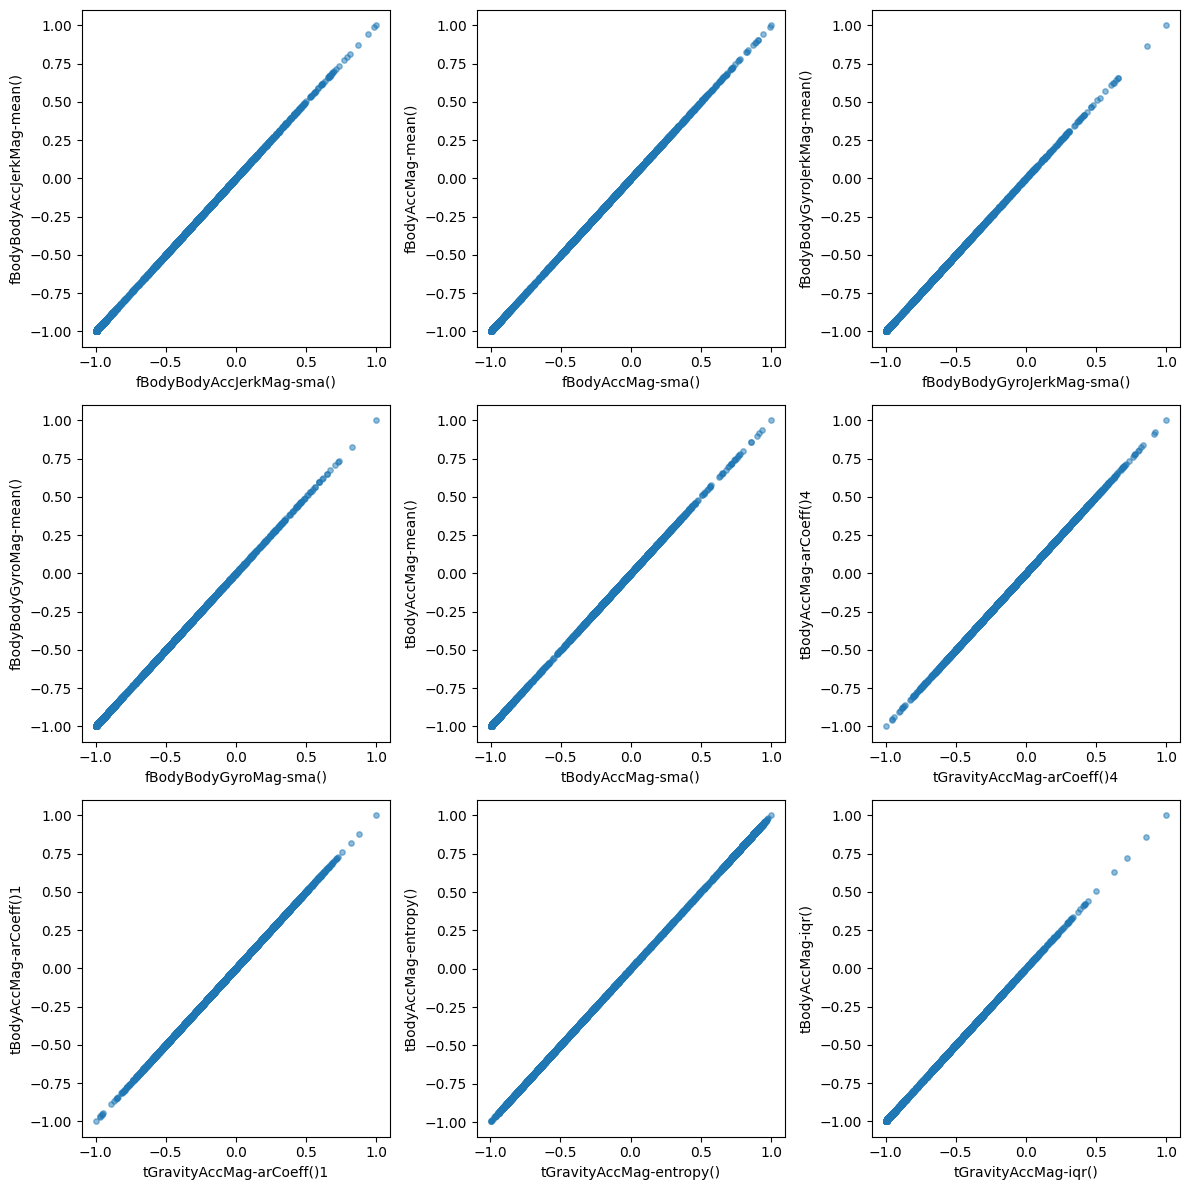

In [81]:
pairs = list(zip(top5["feature_1"], top5["feature_2"]))

plot_feature_pairs_scatter(df, pairs)